In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#read 
df = pd.read_csv("fake reviews dataset.csv")

In [6]:
#columns
print(df.columns)

Index(['category', 'rating', 'label', 'text_'], dtype='object')


In [7]:
#head
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [8]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [9]:
#label value check
print(df['label'].value_counts())

label
CG    20216
OR    20216
Name: count, dtype: int64


In [10]:
#shape
df.shape

(40432, 4)

In [11]:
#null value
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [12]:
#duplicate row
df.duplicated().sum()

np.int64(12)

In [13]:
#describe
df.describe()

,rating
count,40432.000000
mean,4.256579
std,1.144354
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [14]:
#label encoding
df['label'] = df['label'].map({
    'CG': 1,
    'OR': 0
})

In [15]:
df['label'].value_counts()

label
1    20216
0    20216
Name: count, dtype: int64

In [16]:
#text clening
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['text_'].apply(clean_text)

In [17]:
df[['text_','clean_text']].head()

,text_,clean_text
0,"Love this! Well made, sturdy, and very comfor...",love this well made sturdy and very comfortab...
1,"love it, a great upgrade from the original. I...",love it a great upgrade from the original ive...
2,This pillow saved my back. I love the look and...,this pillow saved my back i love the look and ...
3,"Missing information on how to use it, but it i...",missing information on how to use it but it is...
4,Very nice set. Good quality. We have had the s...,very nice set good quality we have had the set...


In [18]:
#tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['label']

In [19]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
#naive bayas
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8706566093730679


In [21]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8986026956844319


In [22]:
#randomforest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8832694447879312


In [23]:
#compare models
print("Naive Bayes:",
      accuracy_score(y_test, y_pred_nb))

print("Logistic Regression:",
      accuracy_score(y_test, y_pred_lr))

print("Random Forest:",
      accuracy_score(y_test, y_pred_rf))

Naive Bayes: 0.8706566093730679
Logistic Regression: 0.8986026956844319
Random Forest: 0.8832694447879312


In [24]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[3691  380]
 [ 440 3576]]


In [25]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4071
           1       0.90      0.89      0.90      4016

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



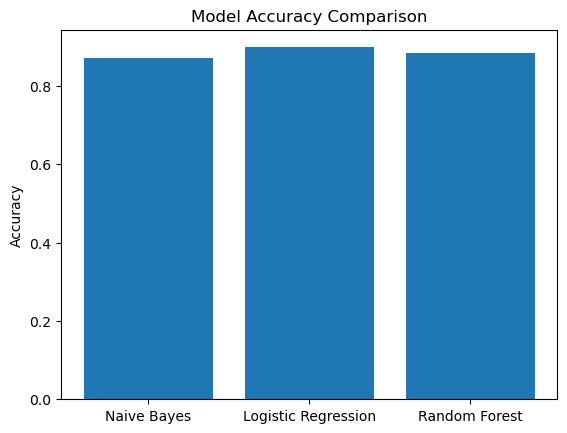

In [26]:
#accuracy comparision graph
import matplotlib.pyplot as plt

models = ['Naive Bayes',
          'Logistic Regression',
          'Random Forest']

accuracy = [0.8707, 0.8986, 0.8834]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [27]:
#final prediction
review = ["This product is amazing and worth buying"]

review = tfidf.transform(review)

prediction = lr.predict(review)

if prediction[0] == 1:
    print("Fake Review")
else:
    print("Genuine Review")

Genuine Review


In [28]:
review = "Amazing amazing amazing product! Perfect in every way."

review_clean = clean_text(review)
review_tfidf = tfidf.transform([review_clean])

prediction = lr.predict(review_tfidf)

print(prediction)

[0]


In [29]:
df = pd.read_csv("Fake Reviews dataset.csv")

print(df[['text_', 'label']].head(20))

                                                text_ label
0   Love this!  Well made, sturdy, and very comfor...    CG
1   love it, a great upgrade from the original.  I...    CG
2   This pillow saved my back. I love the look and...    CG
3   Missing information on how to use it, but it i...    CG
4   Very nice set. Good quality. We have had the s...    CG
5        I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.    CG
6   They are the perfect touch for me and the only...    CG
7   These done fit well and look great.  I love th...    CG
8   Great big numbers & easy to read, the only thi...    CG
9   My son loves this comforter and it is very wel...    CG
10  As advertised. 5th one I've had. The only prob...    CG
11  Very handy for one of my kids and the tools ar...    CG
12  Did someone say, "Oriental for $60"?  It is a ...    CG
13  These are so flimsy! They are not the quality ...    CG
14  Makes may tea with out stirring. The only prob...    CG
15  Absolutely adorable! And excellent p

In [30]:
review1 = "The product arrived on time and works exactly as described."
review2 = "Best product ever made in the history of the universe. Everyone should buy it immediately."

for review in [review1, review2]:
    review_clean = clean_text(review)
    review_tfidf = tfidf.transform([review_clean])

    print("Review:", review)
    print("Prediction:", lr.predict(review_tfidf))
    print("Probability:", lr.predict_proba(review_tfidf))
    print()

Review: The product arrived on time and works exactly as described.
Prediction: [0]
Probability: [[0.78172625 0.21827375]]

Review: Best product ever made in the history of the universe. Everyone should buy it immediately.
Prediction: [0]
Probability: [[0.86183961 0.13816039]]



In [31]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['text_'].apply(clean_text)

In [32]:
print(df.columns)

Index(['category', 'rating', 'label', 'text_', 'clean_text'], dtype='object')


In [33]:
idx = 500

review = df['clean_text'].iloc[idx]

print("Review:", review)
print("Actual:", df['label'].iloc[idx])

pred = lr.predict(tfidf.transform([review]))

print("Predicted:", pred[0])

Review: its working well so far we have the wide wooden legs of a travel trailer the upright
Actual: CG
Predicted: 1


In [34]:
print(df['label'].value_counts())

label
CG    20216
OR    20216
Name: count, dtype: int64


In [35]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

In [36]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.901323111166069


In [37]:
print(df['label'].unique())

['CG' 'OR']


In [38]:
print(df[df['label']=='CG']['text_'].iloc[0])

Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty


In [39]:
print(df[df['label']=='OR']['text_'].iloc[0])

These are just perfect, exactly what I was looking for.
